In [15]:
import pandas as pd

# Load the cleaned dataset created in 01_data_exploration.ipynb
df = pd.read_csv("../data/processed/cleaned_transactions.csv")

# Check the number of rows and columns
df.shape

(148401, 21)

In [16]:
# Separate the target variable from the input features
# y = what we want the model to predict
# X = everything the model can use to make that prediction

y = df["TRANS_VALUE"]

# Remove TRANS_VALUE because it is our target
# Remove PRICE_PER_SQM because it is calculated directly from TRANS_VALUE
# Keeping it would cause data leakage

X = df.drop(columns=["TRANS_VALUE", "PRICE_PER_SQM"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (148401, 19)
y shape: (148401,)


In [17]:
from sklearn.model_selection import train_test_split

# Split the data before preprocessing.
# 80% will be used to train the model.
# 20% will be kept completely unseen for final testing.
# random_state=42 makes the split reproducible.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (118720, 19)
X_test: (29681, 19)
y_train: (118720,)
y_test: (29681,)


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify text/categorical columns and numerical columns
categorical_cols = X_train.select_dtypes(include="str").columns
numerical_cols = X_train.select_dtypes(include="number").columns

print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numerical_cols))

# OneHotEncoder converts categories such as "Business Bay" and "Flat"
# into numerical columns that ML models can understand.
#
# handle_unknown="ignore" prevents errors if a category appears in the
# test set that wasn't present in the training set.
#
# sparse_output=True keeps the encoded data memory-efficient because
# we have many categorical values, especially PROJECT_EN and PROCEDURE_EN.

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

Categorical columns: 14
Numerical columns: 5


In [19]:
print(categorical_cols)
print(numerical_cols)

Index(['GROUP_EN', 'PROCEDURE_EN', 'IS_OFFPLAN_EN', 'IS_FREE_HOLD_EN',
       'USAGE_EN', 'AREA_EN', 'PROP_TYPE_EN', 'PROP_SB_TYPE_EN', 'ROOMS_EN',
       'PARKING', 'NEAREST_METRO_EN', 'NEAREST_MALL_EN', 'NEAREST_LANDMARK_EN',
       'PROJECT_EN'],
      dtype='str')
Index(['PROCEDURE_AREA', 'ACTUAL_AREA', 'YEAR', 'MONTH', 'DAY_OF_WEEK'], dtype='str')


In [20]:
# Learn the categorical mappings from the training data
# and transform both training and test data using the same mappings.
#
# IMPORTANT:
# We use fit_transform() only on X_train.
# We use transform() on X_test.
# This prevents information from the test set leaking into training.

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (118720, 16590)
X_test_processed shape: (29681, 16590)


In [21]:
from sklearn.ensemble import RandomForestRegressor

# Start with a small forest so we can establish a baseline quickly.
# We can increase the number of trees later if needed.

model = RandomForestRegressor(
    n_estimators=30,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# Train the model on the processed training data.
model.fit(X_train_processed, y_train)

print("Model training complete.")

Model training complete.


In [22]:
# Use the trained model to predict transaction values
# for transactions the model has never seen before.

y_pred = model.predict(X_test_processed)

# Check a few predictions
print(y_pred[:10])

[5221959.82226554 1355262.56647084 2867091.06113339 1346229.65592453
 1200984.50260849 1673810.64019805 4126749.37936427  432697.98637628
  963660.32194063 1120258.91414277]


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Compare the model's predictions (y_pred) with the actual prices (y_test).

mae = mean_absolute_error(y_test, y_pred)

# RMSE gives more weight to large prediction errors.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R² tells us how much of the variation in transaction value
# is explained by the model.
r2 = r2_score(y_test, y_pred)

print(f"MAE:  AED {mae:,.2f}")
print(f"RMSE: AED {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  AED 1,100,590.10
RMSE: AED 17,507,614.15
R²:   0.3325


In [24]:
# Check the distribution of transaction values.
# The max value is extremely large compared with the median,
# so we expect a heavily right-skewed target.

print(y.describe())

# Check the largest transaction values.
print("\nTop 10 transaction values:")
print(y.nlargest(10))

count    1.484010e+05
mean     3.526703e+06
std      3.629395e+07
min      1.633500e+02
25%      8.150000e+05
50%      1.409800e+06
75%      2.712349e+06
max      1.034807e+10
Name: TRANS_VALUE, dtype: float64

Top 10 transaction values:
129145    1.034807e+10
118092    4.250000e+09
140449    3.130255e+09
124896    2.594830e+09
120374    1.750000e+09
94228     1.713544e+09
115635    1.713544e+09
140450    1.461866e+09
131523    1.426328e+09
125458    1.311384e+09
Name: TRANS_VALUE, dtype: float64


In [25]:
import numpy as np

# Log-transform the target.
# This compresses extremely large transaction values and makes
# the target distribution easier for the model to learn.
#
# log1p(x) = log(1 + x), which is safe even if a value is 0.

y_log = np.log1p(y)

# Check how the transformed target looks
print(y_log.describe())

count    148401.000000
mean         14.291173
std           0.965110
min           5.101998
25%          13.610945
50%          14.158959
75%          14.813326
max          23.060066
Name: TRANS_VALUE, dtype: float64


In [26]:
# Create the training and testing targets in log scale.
# X_train and X_test remain exactly the same.

y_train_log = y_log.loc[y_train.index]
y_test_log = y_log.loc[y_test.index]

print("y_train_log:", y_train_log.shape)
print("y_test_log:", y_test_log.shape)

y_train_log: (118720,)
y_test_log: (29681,)


In [27]:
from sklearn.ensemble import RandomForestRegressor

# Train the same model architecture, but this time on log-transformed prices.
# This reduces the influence of extreme multi-billion-AED transactions.

log_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

log_model.fit(X_train_processed, y_train_log)

print("Log-target model training complete.")

Log-target model training complete.


In [28]:
# Predict prices in log scale
y_pred_log = log_model.predict(X_test_processed)

# Convert predictions back to AED.
# expm1 reverses the earlier log1p transformation.

y_pred_original = np.expm1(y_pred_log)

print(y_pred_original[:10])

[4821622.50302445 1345539.05400321 2794923.68653766  899674.16625258
 1192458.18559154 1663802.17660612 3939134.45142751  463126.81573261
  962795.6442197   982626.60216219]


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Compare predictions converted back to AED against the actual transaction values.

mae_log = mean_absolute_error(y_test, y_pred_original)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_original))
r2_log = r2_score(y_test, y_pred_original)

print(f"MAE:  AED {mae_log:,.2f}")
print(f"RMSE: AED {rmse_log:,.2f}")
print(f"R²:   {r2_log:.4f}")

MAE:  AED 979,068.94
RMSE: AED 13,817,712.06
R²:   0.5842


In [30]:
# Get the feature names created by OneHotEncoder.
# This lets us connect the model's importance scores back to
# the original property characteristics.

feature_names = preprocessor.get_feature_names_out()

# Get the importance of every encoded feature.
importances = log_model.feature_importances_

# Create a DataFrame so we can sort the features by importance.
feature_importance = pd.DataFrame({
    "FEATURE": feature_names,
    "IMPORTANCE": importances
}).sort_values("IMPORTANCE", ascending=False)

# Display the 20 most important features.
feature_importance.head(20)

,FEATURE,IMPORTANCE
16585,num__PROCEDURE_AREA,0.635737
28,cat__PROCEDURE_EN_Mortgage Registration,0.039029
1,cat__GROUP_EN_Mortgage,0.030656
16586,num__ACTUAL_AREA,0.029344
38,cat__PROCEDURE_EN_Sell - Pre registration,0.026460
43,cat__IS_FREE_HOLD_EN_Free Hold,0.019438
13615,cat__NEAREST_MALL_EN_Dubai Mall,0.018916
46,cat__USAGE_EN_Residential,0.006884
16588,num__MONTH,0.006533
311,cat__AREA_EN_Warsan Fourth,0.005414


In [31]:
# Check the relationship between the numerical features and transaction value.
# A very strong correlation can indicate that a feature is closely tied
# to the target and may need special handling.

df[[
    "TRANS_VALUE",
    "PROCEDURE_AREA",
    "ACTUAL_AREA"
]].corr()

,TRANS_VALUE,PROCEDURE_AREA,ACTUAL_AREA
TRANS_VALUE,1.000000,0.312408,0.306171
PROCEDURE_AREA,0.312408,1.000000,0.998826
ACTUAL_AREA,0.306171,0.998826,1.000000


In [32]:
# Look at transactions where PROCEDURE_AREA is extremely large.
# These may be land transactions or unusual records influencing the model.

df.nlargest(20, "PROCEDURE_AREA")[[
    "TRANS_VALUE",
    "PROCEDURE_AREA",
    "ACTUAL_AREA",
    "AREA_EN",
    "PROP_TYPE_EN",
    "PROP_SB_TYPE_EN"
]]

,TRANS_VALUE,PROCEDURE_AREA,ACTUAL_AREA,AREA_EN,PROP_TYPE_EN,PROP_SB_TYPE_EN
125458,1.311384e+09,6718633.78,6718633.78,Saih Aldahal,Land,Government Housing
125460,1.311384e+09,6718306.93,6718306.93,Saih Aldahal,Land,Government Housing
119366,4.575000e+08,5579951.13,5579951.13,Al Marmoom,Land,Commercial
125459,1.311384e+09,4478819.00,4478819.00,Saih Aldahal,Land,Government Housing
124896,2.594830e+09,1706068.25,1706068.25,Al Yufrah 1,Land,Commercial
97224,5.846212e+08,1201279.59,1201279.59,Warsan Fourth,Land,Commercial
129145,1.034807e+10,1185058.10,1185056.87,DUBAI WATER FRONT,Land,Commercial
116191,2.500000e+08,1160623.24,1160623.75,Al Eyas,Land,Commercial
131523,1.426328e+09,1088060.04,1088060.04,Al Yelayiss 1,Land,Unknown
129144,7.514364e+08,1073270.46,1073526.03,DUBAI WATER FRONT,Land,Commercial


In [33]:
from catboost import CatBoostRegressor

# CatBoost can handle categorical variables directly,
# so we don't need the 16,590-column OneHotEncoder matrix.
#
# We train on the log-transformed target because our transaction
# values are extremely right-skewed.

cat_model = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.08,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

# CatBoost needs categorical columns represented as strings.
# Fill missing categorical values with a consistent label.

X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

for col in categorical_cols:
    X_train_cat[col] = X_train_cat[col].fillna("Unknown").astype(str)
    X_test_cat[col] = X_test_cat[col].fillna("Unknown").astype(str)

# Train using the original categorical columns rather than one-hot encoding.
cat_model.fit(
    X_train_cat,
    y_train_log,
    cat_features=list(categorical_cols)
)

print("CatBoost training complete.")

0:	learn: 0.9101311	total: 370ms	remaining: 3m 4s
100:	learn: 0.3545171	total: 19.4s	remaining: 1m 16s
200:	learn: 0.3292222	total: 38.6s	remaining: 57.4s
300:	learn: 0.3152818	total: 58.4s	remaining: 38.6s
400:	learn: 0.3062247	total: 1m 17s	remaining: 19.2s
499:	learn: 0.2986081	total: 1m 38s	remaining: 0us
CatBoost training complete.


In [34]:
# Check whether CatBoost can be imported into the current kernel
import catboost

print(catboost.__version__)

1.2.10


In [35]:
from catboost import CatBoostRegressor

# Make copies so we don't modify X_train/X_test.
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

# CatBoost handles categorical features directly.
# Missing categorical values are replaced with "Unknown".
for col in categorical_cols:
    X_train_cat[col] = X_train_cat[col].fillna("Unknown").astype(str)
    X_test_cat[col] = X_test_cat[col].fillna("Unknown").astype(str)

# Train on the log-transformed target to reduce the influence
# of extreme multi-billion-AED transactions.

cat_model = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.08,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train_cat,
    y_train_log,
    cat_features=list(categorical_cols)
)

print("CatBoost training complete.")

0:	learn: 0.9101311	total: 165ms	remaining: 1m 22s
100:	learn: 0.3545171	total: 17.8s	remaining: 1m 10s
200:	learn: 0.3292222	total: 36.1s	remaining: 53.7s
300:	learn: 0.3152818	total: 55s	remaining: 36.4s
400:	learn: 0.3062247	total: 1m 13s	remaining: 18.2s
499:	learn: 0.2986081	total: 1m 32s	remaining: 0us
CatBoost training complete.


In [36]:
# Predict transaction values in log scale
y_pred_cat_log = cat_model.predict(X_test_cat)

# Convert the predictions back to the original AED scale
y_pred_cat = np.expm1(y_pred_cat_log)

# Check the first 10 predictions
print(y_pred_cat[:10])

[3401747.50622865 1407584.11884884 2906591.0781719   915654.55422278
 1240633.176659   1726628.20960198 4150882.06939105  374453.15306721
  883540.55355376  971033.91654033]


In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Compare CatBoost predictions with the actual transaction values.

mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2_cat = r2_score(y_test, y_pred_cat)

print(f"MAE:  AED {mae_cat:,.2f}")
print(f"RMSE: AED {rmse_cat:,.2f}")
print(f"R²:   {r2_cat:.4f}")


MAE:  AED 1,048,076.96
RMSE: AED 16,451,414.60
R²:   0.4106


In [38]:
# Create a results DataFrame so we can inspect individual predictions.

results = pd.DataFrame({
    "ACTUAL": y_test,
    "PREDICTED": y_pred_original
})

# Calculate the absolute prediction error.
results["ABS_ERROR"] = abs(results["ACTUAL"] - results["PREDICTED"])

# Calculate percentage error.
results["ERROR_PCT"] = (
    results["ABS_ERROR"] / results["ACTUAL"]
) * 100

# Show the 10 predictions with the largest absolute errors.
results.sort_values("ABS_ERROR", ascending=False).head(10)

,ACTUAL,PREDICTED,ABS_ERROR,ERROR_PCT
115635,1.713544e+09,6.500697e+08,1.063474e+09,62.062844
117791,1.250000e+08,8.730472e+08,7.480472e+08,598.437757
148225,1.194601e+09,4.681658e+08,7.264349e+08,60.809851
148218,1.194601e+09,4.681658e+08,7.264349e+08,60.809851
87221,1.000000e+07,7.258509e+08,7.158509e+08,7158.508691
123968,6.750000e+08,6.351778e+07,6.114822e+08,90.589958
117273,6.493200e+08,8.225922e+07,5.670608e+08,87.331483
131523,1.426328e+09,9.426207e+08,4.837069e+08,33.912751
124980,4.660000e+08,2.851530e+07,4.374847e+08,93.880837
112888,4.180000e+08,2.521474e+07,3.927853e+08,93.967764


In [39]:
# Inspect the worst prediction errors together with their original features.
# This helps us understand whether these are unusual transactions,
# land deals, mortgages, duplicate-related records, or data-quality issues.

worst_indices = results.nlargest(10, "ABS_ERROR").index

df.loc[worst_indices, [
    "GROUP_EN",
    "PROCEDURE_EN",
    "TRANS_VALUE",
    "ACTUAL_AREA",
    "AREA_EN",
    "PROP_TYPE_EN",
    "PROP_SB_TYPE_EN",
    "PROJECT_EN",
    "ROOMS_EN",
    "PARKING"
]].sort_values("TRANS_VALUE", ascending=False)

,GROUP_EN,PROCEDURE_EN,TRANS_VALUE,ACTUAL_AREA,AREA_EN,PROP_TYPE_EN,PROP_SB_TYPE_EN,PROJECT_EN,ROOMS_EN,PARKING
115635,Mortgage,Mortgage Registration,1.713544e+09,167375.99,Al Rowaiyah First,Land,Unknown,Greenz By Danube,Unknown,Unknown
131523,Sales,Delayed Sell,1.426328e+09,1088060.04,Al Yelayiss 1,Land,Unknown,Unknown,Unknown,Unknown
148218,Gifts,Grant,1.194601e+09,114527.60,PALM JUMEIRAH,Unit,Sized Partition,FAIRMONT PALM HOTEL & RESORT,Unknown,295
148225,Gifts,Grant,1.194601e+09,114527.60,PALM JUMEIRAH,Unit,Sized Partition,FAIRMONT PALM HOTEL & RESORT,Unknown,295
123968,Sales,Development Registration,6.750000e+08,7343.27,BARSHA HEIGHTS,Land,Commercial,Unknown,Unknown,Unknown
117273,Mortgage,Mortgage Registration,6.493200e+08,4694.39,BUSINESS BAY,Land,Residential,Unknown,Unknown,Unknown
124980,Mortgage,Modify Mortgage,4.660000e+08,22488.79,DUBAI INTERNATIONAL ACADEMIC CITY,Land,Residential,Unknown,Unknown,Unknown
112888,Mortgage,Mortgage Registration,4.180000e+08,4238.10,Al Nahda First,Land,Unknown,Unknown,Unknown,Unknown
117791,Mortgage,Mortgage Registration,1.250000e+08,252762.80,THE WORLD,Land,Commercial,Unknown,Unknown,Unknown
87221,Sales,Sale,1.000000e+07,476575.89,CITY OF ARABIA,Land,Residential,Unknown,Unknown,Unknown


In [40]:
# Remove the top 1% of transaction values from the evaluation only.
# We are NOT deleting them from the dataset.
# This tells us how the model performs on the more typical market.

threshold = y_test.quantile(0.99)

normal_mask = y_test <= threshold

mae_normal = mean_absolute_error(
    y_test[normal_mask],
    y_pred_original[normal_mask]
)

rmse_normal = np.sqrt(
    mean_squared_error(
        y_test[normal_mask],
        y_pred_original[normal_mask]
    )
)

r2_normal = r2_score(
    y_test[normal_mask],
    y_pred_original[normal_mask]
)

print(f"99th percentile threshold: AED {threshold:,.2f}")
print(f"MAE:  AED {mae_normal:,.2f}")
print(f"RMSE: AED {rmse_normal:,.2f}")
print(f"R²:   {r2_normal:.4f}")

99th percentile threshold: AED 31,500,000.00
MAE:  AED 495,316.02
RMSE: AED 4,545,406.97
R²:   -0.6830


In [41]:
# Check how transaction values are distributed across property types.
# This helps us see whether we're trying to predict very different
# markets with one model.

df.groupby("PROP_TYPE_EN")["TRANS_VALUE"].agg(
    ["count", "median", "mean", "max"]
).sort_values("count", ascending=False)

,count,median,mean,max
PROP_TYPE_EN,,,,
Unit,118298,1203355.36,1.940372e+06,1.194601e+09
Land,17376,4200000.00,1.408948e+07,1.034807e+10
Building,12727,2982000.00,3.850503e+06,7.250000e+08


In [42]:
# Check transaction values by procedure.
# Mortgage, sale, development registration, etc. can represent
# fundamentally different types of transactions.
#
# If they have very different price distributions, this can make
# a single model much harder to train.

df.groupby("GROUP_EN")["TRANS_VALUE"].agg(
    ["count", "median", "mean", "max"]
).sort_values("count", ascending=False)

,count,median,mean,max
GROUP_EN,,,,
Sales,112033,1425000.000,3.122557e+06,3.130255e+09
Mortgage,30468,1258171.000,4.406524e+06,1.034807e+10
Gifts,5900,2006330.935,6.657441e+06,1.194601e+09


In [43]:
# Filter to actual Sales transactions.
# This gives the model a much cleaner prediction problem:
# predicting the value of a property sale rather than mixing
# Sales, Mortgages, and Gifts together.

sales_df = df[df["GROUP_EN"] == "Sales"].copy()

print("Sales transactions:", len(sales_df))
print("Sales percentage:", f"{len(sales_df) / len(df) * 100:.2f}%")

Sales transactions: 112033
Sales percentage: 75.49%


In [44]:
# Examine the distribution of sale values.
# We will use this to determine whether another log transformation
# and/or outlier treatment is appropriate.

sales_df["TRANS_VALUE"].describe()

count    1.120330e+05
mean     3.122557e+06
std      1.666481e+07
min      1.633500e+02
25%      8.233602e+05
50%      1.425000e+06
75%      2.750000e+06
max      3.130255e+09
Name: TRANS_VALUE, dtype: float64

In [45]:
# Use only Sales transactions for the prediction model.
# GROUP_EN is no longer useful as a feature because every row is "Sales".

sales_df = sales_df.copy()

# Drop GROUP_EN because it has only one value in this dataset.
# Drop TRANS_VALUE because it is our target.
# Drop PRICE_PER_SQM because it is calculated from TRANS_VALUE
# and would cause target leakage.

X_sales = sales_df.drop(
    columns=["GROUP_EN", "TRANS_VALUE", "PRICE_PER_SQM"]
)

y_sales = sales_df["TRANS_VALUE"]

print("X_sales shape:", X_sales.shape)
print("y_sales shape:", y_sales.shape)

X_sales shape: (112033, 18)
y_sales shape: (112033,)


In [46]:
from sklearn.model_selection import train_test_split

# Split Sales transactions into training and testing sets.
# The test set remains completely unseen during training.

X_sales_train, X_sales_test, y_sales_train, y_sales_test = train_test_split(
    X_sales,
    y_sales,
    test_size=0.2,
    random_state=42
)

print("X_sales_train:", X_sales_train.shape)
print("X_sales_test:", X_sales_test.shape)
print("y_sales_train:", y_sales_train.shape)
print("y_sales_test:", y_sales_test.shape)

X_sales_train: (89626, 18)
X_sales_test: (22407, 18)
y_sales_train: (89626,)
y_sales_test: (22407,)


In [47]:
# Identify categorical and numerical columns in the Sales dataset.
# We keep this separate from the earlier full-dataset preprocessing.

sales_categorical_cols = X_sales_train.select_dtypes(include="str").columns
sales_numerical_cols = X_sales_train.select_dtypes(include="number").columns

print("Categorical columns:", len(sales_categorical_cols))
print("Numerical columns:", len(sales_numerical_cols))

print("\nCategorical:")
print(list(sales_categorical_cols))

print("\nNumerical:")
print(list(sales_numerical_cols))

Categorical columns: 13
Numerical columns: 5

Categorical:
['PROCEDURE_EN', 'IS_OFFPLAN_EN', 'IS_FREE_HOLD_EN', 'USAGE_EN', 'AREA_EN', 'PROP_TYPE_EN', 'PROP_SB_TYPE_EN', 'ROOMS_EN', 'PARKING', 'NEAREST_METRO_EN', 'NEAREST_MALL_EN', 'NEAREST_LANDMARK_EN', 'PROJECT_EN']

Numerical:
['PROCEDURE_AREA', 'ACTUAL_AREA', 'YEAR', 'MONTH', 'DAY_OF_WEEK']


In [48]:
# Sale prices are heavily right-skewed.
# Log transformation reduces the influence of extremely expensive properties.

y_sales_train_log = np.log1p(y_sales_train)
y_sales_test_log = np.log1p(y_sales_test)

print(y_sales_train_log.describe())

count    89626.000000
mean        14.305245
std          0.946838
min          5.101998
25%         13.623140
50%         14.173463
75%         14.827112
max         21.864380
Name: TRANS_VALUE, dtype: float64


In [49]:
from catboost import CatBoostRegressor

# Make copies so the original training/test data stays unchanged.
X_sales_train_cat = X_sales_train.copy()
X_sales_test_cat = X_sales_test.copy()

# CatBoost handles categorical features directly.
# Replace missing categorical values with "Unknown".
for col in sales_categorical_cols:
    X_sales_train_cat[col] = (
        X_sales_train_cat[col]
        .fillna("Unknown")
        .astype(str)
    )
    
    X_sales_test_cat[col] = (
        X_sales_test_cat[col]
        .fillna("Unknown")
        .astype(str)
    )

# Train the Sales-only model on log-transformed transaction values.
cat_sales_model = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.08,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

cat_sales_model.fit(
    X_sales_train_cat,
    y_sales_train_log,
    cat_features=list(sales_categorical_cols)
)

print("Sales CatBoost training complete.")

0:	learn: 0.8900588	total: 190ms	remaining: 1m 35s
100:	learn: 0.3248724	total: 16.3s	remaining: 1m 4s
200:	learn: 0.2985772	total: 32s	remaining: 47.6s
300:	learn: 0.2851226	total: 48.2s	remaining: 31.8s
400:	learn: 0.2757668	total: 1m 4s	remaining: 15.9s
499:	learn: 0.2676716	total: 1m 21s	remaining: 0us
Sales CatBoost training complete.


In [50]:
# Predict sale prices in log scale.
y_sales_pred_log = cat_sales_model.predict(X_sales_test_cat)

# Convert predictions back to AED.
y_sales_pred = np.expm1(y_sales_pred_log)

# Calculate regression metrics on the original AED values.
mae_sales = mean_absolute_error(y_sales_test, y_sales_pred)
rmse_sales = np.sqrt(
    mean_squared_error(y_sales_test, y_sales_pred)
)
r2_sales = r2_score(y_sales_test, y_sales_pred)

print(f"MAE:  AED {mae_sales:,.2f}")
print(f"RMSE: AED {rmse_sales:,.2f}")
print(f"R²:   {r2_sales:.4f}")

MAE:  AED 805,576.46
RMSE: AED 16,051,546.49
R²:   0.2623


In [51]:
# Compare all models we trained.
# This gives us a single record of our experiments.

model_comparison = pd.DataFrame({
    "MODEL": [
        "Random Forest",
        "Random Forest + Log Target",
        "CatBoost + Log Target (All Transactions)",
        "CatBoost + Log Target (Sales Only)"
    ],
    "MAE_AED": [
        1100590.10,
        979068.94,
        1048076.96,
        805576.46
    ],
    "RMSE_AED": [
        17507614.15,
        13817712.06,
        16451414.60,
        16051546.49
    ],
    "R2": [
        0.3325,
        0.5842,
        0.4106,
        0.2623
    ]
})

# Higher R² and lower MAE/RMSE are better.
model_comparison.sort_values("R2", ascending=False)

,MODEL,MAE_AED,RMSE_AED,R2
1,Random Forest + Log Target,979068.94,13817712.06,0.5842
2,CatBoost + Log Target (All Transactions),1048076.96,16451414.60,0.4106
0,Random Forest,1100590.10,17507614.15,0.3325
3,CatBoost + Log Target (Sales Only),805576.46,16051546.49,0.2623


In [52]:
# Create a DataFrame containing actual and predicted prices.
# This will be used for error analysis and visualization.

prediction_results = pd.DataFrame({
    "ACTUAL_PRICE": y_test.values,
    "PREDICTED_PRICE": y_pred_original
})

# Calculate the absolute prediction error.
prediction_results["ABS_ERROR"] = (
    prediction_results["ACTUAL_PRICE"]
    - prediction_results["PREDICTED_PRICE"]
).abs()

# Calculate percentage error.
# Replace zero actual values with NaN to avoid division by zero.

prediction_results["ERROR_PCT"] = (
    prediction_results["ABS_ERROR"]
    / prediction_results["ACTUAL_PRICE"].replace(0, np.nan)
) * 100

prediction_results.head()

,ACTUAL_PRICE,PREDICTED_PRICE,ABS_ERROR,ERROR_PCT
0,2257597.00,4.821623e+06,2.564026e+06,113.573215
1,1353380.00,1.345539e+06,7.840946e+03,0.579360
2,2825000.00,2.794924e+06,3.007631e+04,1.064648
3,828193.00,8.996742e+05,7.148117e+04,8.630979
4,1069489.51,1.192458e+06,1.229687e+05,11.497885


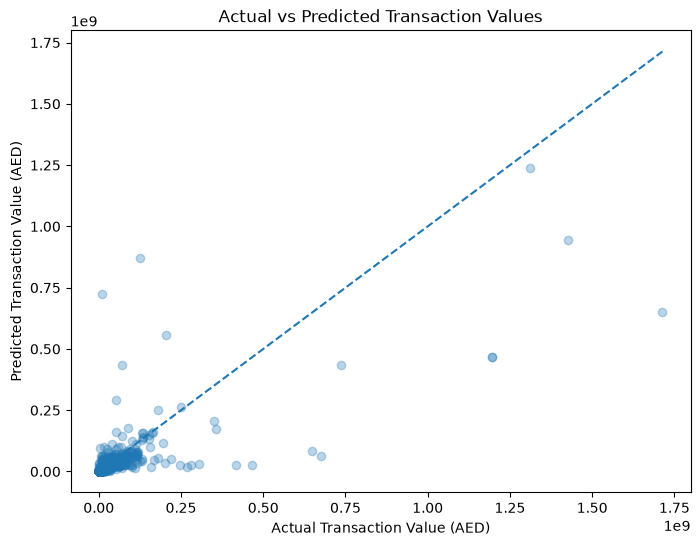

In [53]:
import matplotlib.pyplot as plt

# Plot actual prices against predicted prices.
# A perfect model would have all points close to the diagonal line.

plt.figure(figsize=(8, 6))

plt.scatter(
    prediction_results["ACTUAL_PRICE"],
    prediction_results["PREDICTED_PRICE"],
    alpha=0.3
)

# Reference line for perfect predictions.
max_value = max(
    prediction_results["ACTUAL_PRICE"].max(),
    prediction_results["PREDICTED_PRICE"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Transaction Value (AED)")
plt.ylabel("Predicted Transaction Value (AED)")
plt.title("Actual vs Predicted Transaction Values")

plt.show()

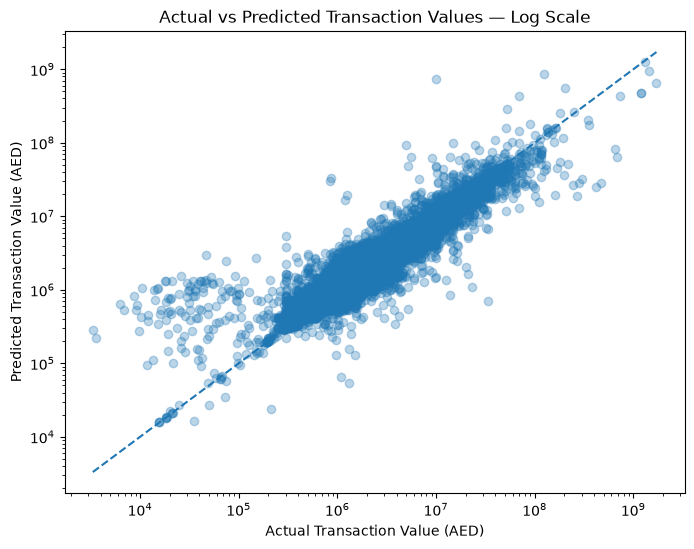

In [54]:
# Plot actual vs predicted prices using a logarithmic scale.
# This makes both normal and high-value transactions visible.

plt.figure(figsize=(8, 6))

plt.scatter(
    prediction_results["ACTUAL_PRICE"],
    prediction_results["PREDICTED_PRICE"],
    alpha=0.3
)

# Reference line for perfect predictions.
positive_values = prediction_results[
    (prediction_results["ACTUAL_PRICE"] > 0) &
    (prediction_results["PREDICTED_PRICE"] > 0)
]

min_value = min(
    positive_values["ACTUAL_PRICE"].min(),
    positive_values["PREDICTED_PRICE"].min()
)

max_value = max(
    positive_values["ACTUAL_PRICE"].max(),
    positive_values["PREDICTED_PRICE"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

# Log scale makes the distribution easier to inspect.
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Actual Transaction Value (AED)")
plt.ylabel("Predicted Transaction Value (AED)")
plt.title("Actual vs Predicted Transaction Values — Log Scale")

plt.show()

In [55]:
# Calculate the median absolute percentage error.
# Median is used because a few extreme transactions can heavily
# distort the average percentage error.

valid_errors = prediction_results[
    prediction_results["ACTUAL_PRICE"] > 0
]["ERROR_PCT"]

median_error_pct = valid_errors.median()

print(f"Median Absolute Percentage Error: {median_error_pct:.2f}%")

Median Absolute Percentage Error: 9.42%


In [56]:
# Divide transactions into practical price bands.
# This shows where the model performs well and where it struggles.

prediction_results["PRICE_SEGMENT"] = pd.cut(
    prediction_results["ACTUAL_PRICE"],
    bins=[
        0,
        1_000_000,
        3_000_000,
        10_000_000,
        50_000_000,
        np.inf
    ],
    labels=[
        "< 1M",
        "1M - 3M",
        "3M - 10M",
        "10M - 50M",
        "50M+"
    ]
)

segment_performance = prediction_results.groupby(
    "PRICE_SEGMENT",
    observed=True
).agg(
    COUNT=("ACTUAL_PRICE", "count"),
    MAE=("ABS_ERROR", "mean"),
    MEDIAN_ERROR_PCT=("ERROR_PCT", "median")
)

segment_performance

,COUNT,MAE,MEDIAN_ERROR_PCT
PRICE_SEGMENT,,,
< 1M,9882,1.261139e+05,8.829977
1M - 3M,13627,2.678823e+05,8.451709
3M - 10M,4822,1.127925e+06,11.993753
10M - 50M,1200,4.841940e+06,13.058010
50M+,150,8.609250e+07,39.846721


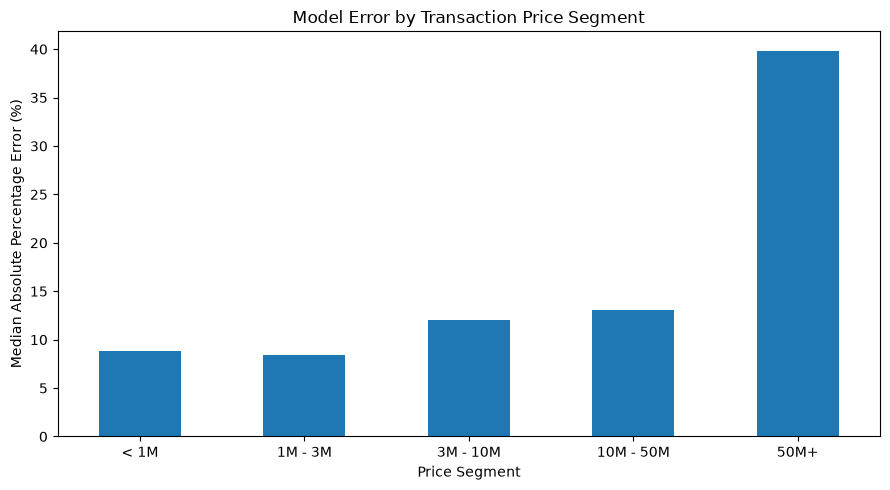

In [57]:
# Plot median percentage error by transaction price segment.
# This makes it easy to identify where model accuracy deteriorates.

plt.figure(figsize=(9, 5))

segment_performance["MEDIAN_ERROR_PCT"].plot(
    kind="bar"
)

plt.xlabel("Price Segment")
plt.ylabel("Median Absolute Percentage Error (%)")
plt.title("Model Error by Transaction Price Segment")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [58]:
# Calculate how many predictions fall within useful error ranges.
# This is a practical metric for a real-estate valuation system.

within_10 = (
    prediction_results["ERROR_PCT"] <= 10
).mean() * 100

within_20 = (
    prediction_results["ERROR_PCT"] <= 20
).mean() * 100

within_30 = (
    prediction_results["ERROR_PCT"] <= 30
).mean() * 100

print(f"Predictions within ±10%: {within_10:.2f}%")
print(f"Predictions within ±20%: {within_20:.2f}%")
print(f"Predictions within ±30%: {within_30:.2f}%")

Predictions within ±10%: 52.07%
Predictions within ±20%: 73.55%
Predictions within ±30%: 84.41%


In [59]:
import os
import joblib

# Create a directory for trained models if it doesn't already exist.
os.makedirs("../models", exist_ok=True)

# Save the trained Random Forest model.
joblib.dump(
    log_model,
    "../models/random_forest_log_model.pkl"
)

# Save the preprocessing pipeline used before the model.
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.
